In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deepeshkansotia/food-delivery-operations-and-customer-analytics")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\viggn\.cache\kagglehub\datasets\deepeshkansotia\food-delivery-operations-and-customer-analytics\versions\1


In [3]:
import os

files = os.listdir(path)
print(files)

['food_delivery_analytics_cleaned.csv']


In [4]:
import pandas as pd
import os

csv_file = os.path.join(path, "food_delivery_analytics_cleaned.csv")
df = pd.read_csv(csv_file)
df.head()
df.sample(5)

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
14089,26ec203e-98c9-4eb8-a88a-1c1c0b01082b,1,43,55.051744,22,5,12,12.447623,54,106,...,112.369248,10,False,False,False,True,False,False,1,33.7
7056,fb8ed782-3962-4e88-be62-66ba74f9a420,3,75,98.076288,12,1,9,39.536241,21,145,...,136.145665,9,False,False,False,False,True,True,10,39.8
8649,5784077e-20fb-490b-afc0-cffaf340ac3b,1,67,10.058887,18,5,6,2.664680,52,69,...,125.012789,4,False,False,False,False,False,False,5,59.0
1335,96d9f805-2aaa-4f97-a307-16aa8314f67a,3,54,12.209309,13,3,6,23.297589,27,105,...,107.165717,5,False,False,False,True,True,False,9,56.0
8566,c41f7a1e-64f0-4825-857c-cb0dcd5d7bf8,3,67,32.599370,20,1,7,22.995661,30,96,...,89.400552,2,False,False,False,False,False,False,12,70.7


In [5]:
df.shape

(15000, 30)

In [6]:
df.columns

Index(['order_id', 'city_tier', 'customer_age', 'customer_loyalty_score',
       'order_hour', 'order_day_of_week', 'order_month',
       'delivery_distance_km', 'preparation_time_minutes',
       'delivery_time_minutes', 'estimated_delivery_time',
       'traffic_level_score', 'weather_severity_score', 'restaurant_rating',
       'delivery_partner_rating', 'customer_rating', 'order_value',
       'delivery_fee', 'discount_amount', 'tip_amount', 'final_amount_paid',
       'number_of_items', 'cancellation_flag', 'delayed_delivery_flag',
       'refund_flag', 'promo_code_used', 'premium_customer_flag',
       'festival_or_weekend_flag', 'delivery_partner_experience_years',
       'delivery_efficiency_score'],
      dtype='object')

In [7]:
print(df.columns.tolist())

['order_id', 'city_tier', 'customer_age', 'customer_loyalty_score', 'order_hour', 'order_day_of_week', 'order_month', 'delivery_distance_km', 'preparation_time_minutes', 'delivery_time_minutes', 'estimated_delivery_time', 'traffic_level_score', 'weather_severity_score', 'restaurant_rating', 'delivery_partner_rating', 'customer_rating', 'order_value', 'delivery_fee', 'discount_amount', 'tip_amount', 'final_amount_paid', 'number_of_items', 'cancellation_flag', 'delayed_delivery_flag', 'refund_flag', 'promo_code_used', 'premium_customer_flag', 'festival_or_weekend_flag', 'delivery_partner_experience_years', 'delivery_efficiency_score']


In [8]:
df.info()
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  object 
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  flo

In [9]:
df.describe()

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,...,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,delivery_partner_experience_years,delivery_efficiency_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,14850.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.253133,46.569667,50.017658,11.470933,3.141933,6.474667,20.133756,32.749667,94.139267,94.140667,...,4.196121,3.993556,113.954265,7.493531,14.932581,12.569739,119.083685,6.489933,8.047600,59.165933
std,0.827951,16.840706,28.771665,6.946134,1.809864,3.454469,11.543488,16.162719,33.597132,32.490455,...,0.391959,0.535016,22.713411,4.352771,8.706253,7.221087,25.798587,3.438123,4.302995,18.102487
min,1.000000,18.000000,0.007172,0.000000,1.000000,1.000000,0.103086,5.000000,10.000000,11.000000,...,2.700000,1.500000,100.000000,0.000432,0.000788,0.000205,72.395550,1.000000,1.000000,1.900000
25%,2.000000,32.000000,25.199828,5.000000,1.000000,3.000000,10.133190,19.000000,68.000000,69.000000,...,3.900000,3.600000,100.000000,3.704018,7.279980,6.396828,101.152407,4.000000,4.000000,46.400000
50%,3.000000,46.000000,50.092268,11.000000,3.000000,7.000000,20.228709,33.000000,95.000000,94.000000,...,4.200000,4.000000,100.000000,7.458605,14.857607,12.629302,113.039544,7.000000,8.000000,59.100000
75%,3.000000,61.000000,74.840432,18.000000,5.000000,9.000000,30.047891,47.000000,120.000000,119.000000,...,4.500000,4.400000,124.153105,11.278689,22.521458,18.848336,130.541371,9.000000,12.000000,72.000000
max,3.000000,75.000000,99.989375,23.000000,6.000000,12.000000,39.998739,60.000000,180.000000,178.000000,...,5.000000,5.000000,215.614574,14.998370,29.999893,24.998828,238.600286,12.000000,15.000000,100.000000


In [10]:
df.isnull().sum()

order_id                               0
city_tier                              0
customer_age                           0
customer_loyalty_score                 0
order_hour                             0
order_day_of_week                      0
order_month                            0
delivery_distance_km                   0
preparation_time_minutes               0
delivery_time_minutes                  0
estimated_delivery_time                0
traffic_level_score                    0
weather_severity_score                 0
restaurant_rating                      0
delivery_partner_rating              150
customer_rating                      150
order_value                            0
delivery_fee                           0
discount_amount                        0
tip_amount                           150
final_amount_paid                      0
number_of_items                        0
cancellation_flag                      0
delayed_delivery_flag                  0
refund_flag     

In [11]:
missing = df.isnull().sum()

missing[missing > 0]

delivery_partner_rating    150
customer_rating            150
tip_amount                 150
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df = df.drop_duplicates()

In [14]:
df.columns

Index(['order_id', 'city_tier', 'customer_age', 'customer_loyalty_score',
       'order_hour', 'order_day_of_week', 'order_month',
       'delivery_distance_km', 'preparation_time_minutes',
       'delivery_time_minutes', 'estimated_delivery_time',
       'traffic_level_score', 'weather_severity_score', 'restaurant_rating',
       'delivery_partner_rating', 'customer_rating', 'order_value',
       'delivery_fee', 'discount_amount', 'tip_amount', 'final_amount_paid',
       'number_of_items', 'cancellation_flag', 'delayed_delivery_flag',
       'refund_flag', 'promo_code_used', 'premium_customer_flag',
       'festival_or_weekend_flag', 'delivery_partner_experience_years',
       'delivery_efficiency_score'],
      dtype='object')

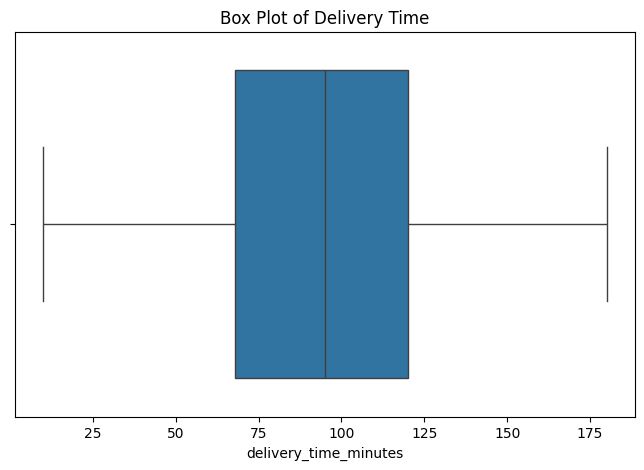

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["delivery_time_minutes"])

plt.title("Box Plot of Delivery Time")

plt.show()

## EDA is done from here

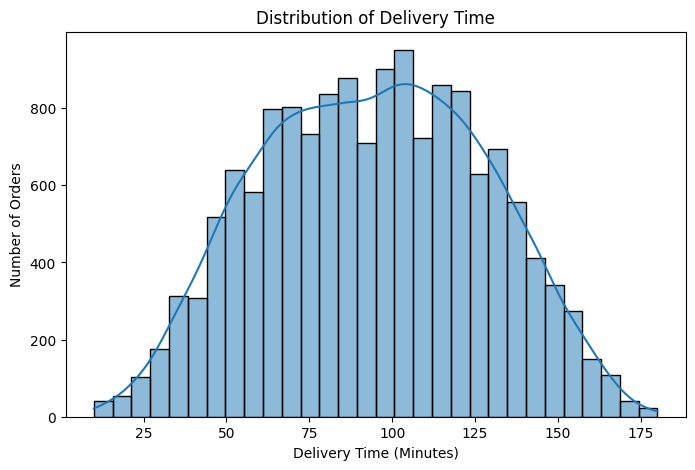

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["delivery_time_minutes"], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")
plt.show()

## from this we can see that most of them get their food by 75 - 125 mins (mostly 100 min)

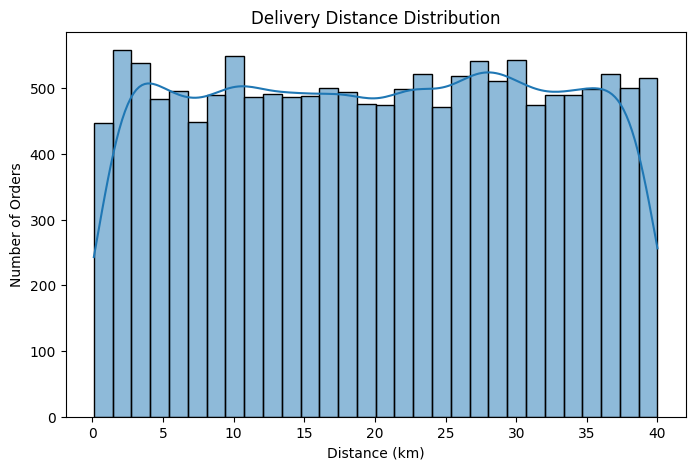

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["delivery_distance_km"], bins=30, kde=True)
plt.title("Delivery Distance Distribution")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Orders")
plt.show()

## all the orders are of equal irrespective of distance

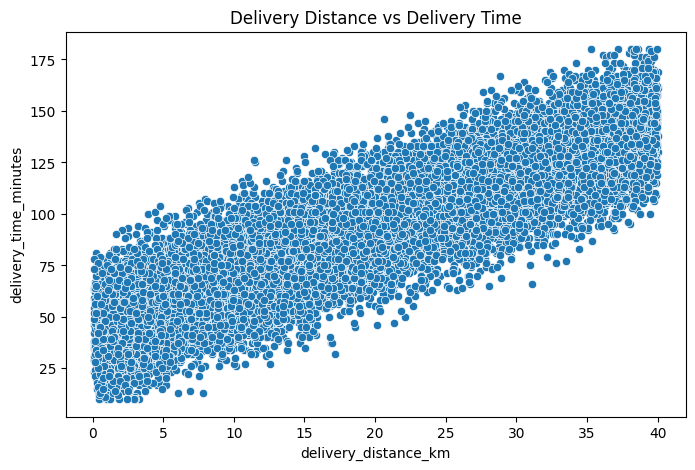

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="delivery_distance_km",
    y="delivery_time_minutes"
)
plt.title("Delivery Distance vs Delivery Time")
plt.show()

## if Dis inc delivery time inc

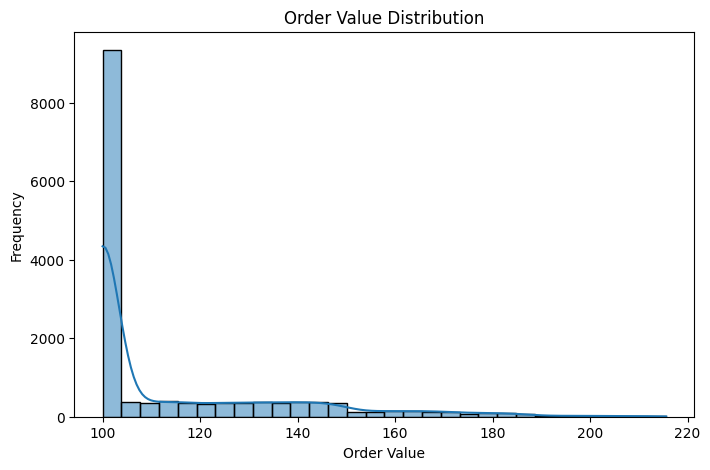

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["order_value"], bins=30, kde=True)
plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

## most orders are of rs 100

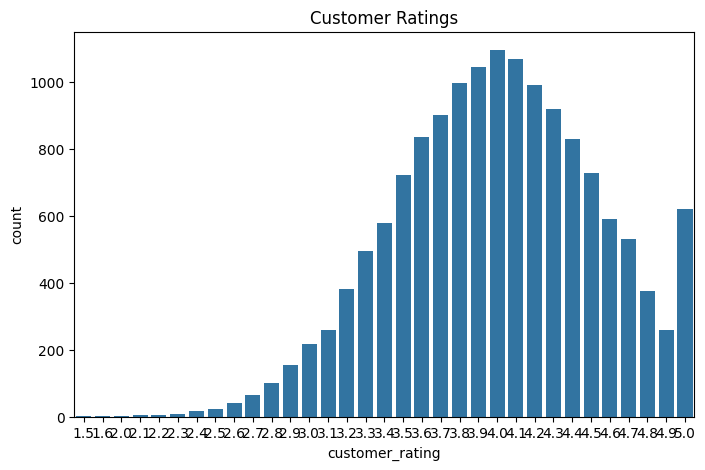

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="customer_rating")
plt.title("Customer Ratings")
plt.show()

## Highest is at.04

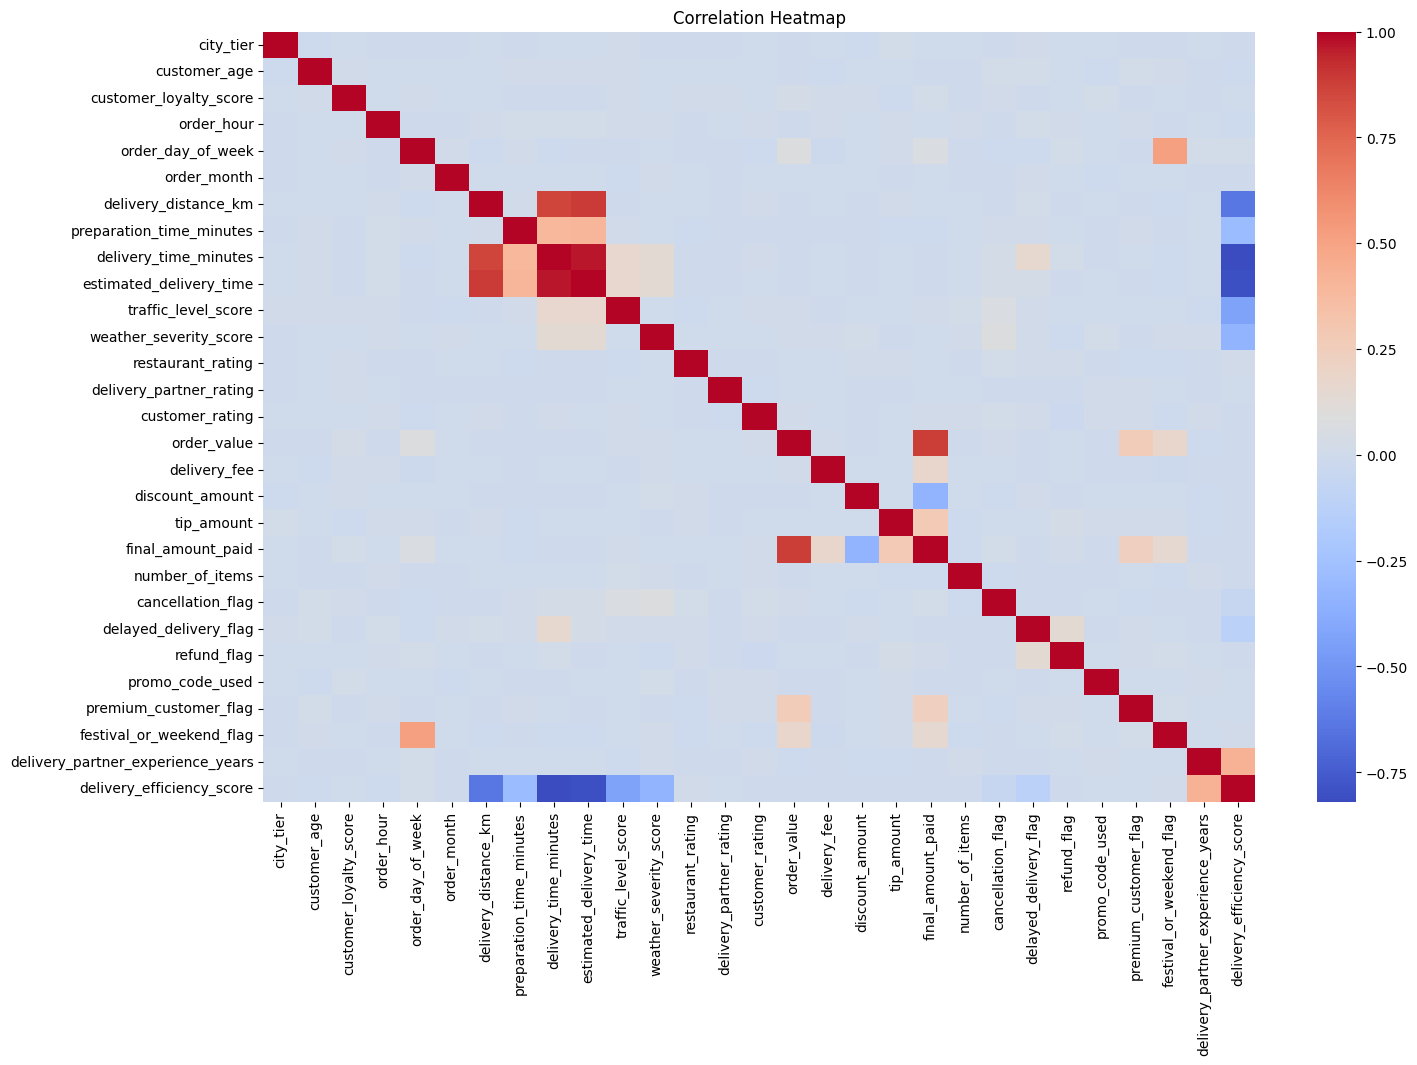

In [21]:
plt.figure(figsize=(16,10))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()

## delivery_distance_km ,preparation_time_minutes ,delivery_time_minutes, estimated_delivery_time  these 4 are inter related +ve relation
## delivery_time_minutes , estimated_delivery_time , delivery_distance_km these 3 are -ve related


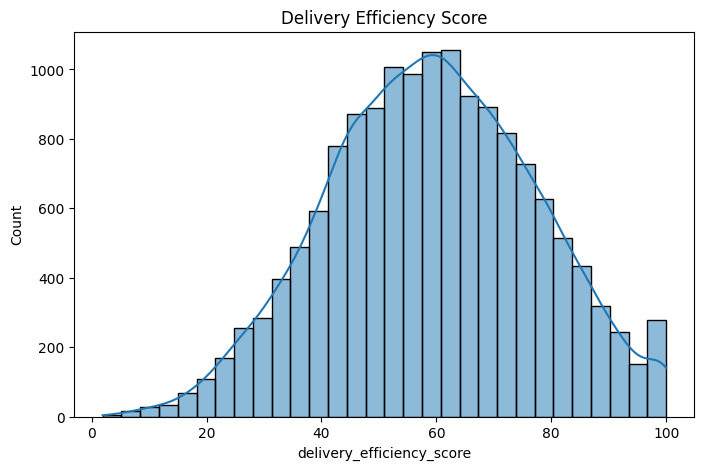

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["delivery_efficiency_score"], bins=30, kde=True)
plt.title("Delivery Efficiency Score")
plt.show()

## this indecates that the between 55 and 65 (hitting over 1,000 orders per bin). This means your average delivery operates slightly better than a 50/100 baseline.

# Target Variable Analysis - delivery_time_minutes all remaining variables will be treated as input features.

In [23]:
target = "delivery_time_minutes"

X = df.drop(columns=[target])
y = df[target]

In [24]:
X = X.drop(columns=["order_id"])
X.head()

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,estimated_delivery_time,traffic_level_score,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,2,21,4.957522,20,6,6,14.117144,23,68,5.4,...,111.563784,4,False,False,True,False,False,True,9,71.1
1,1,63,38.744721,0,2,2,9.177354,16,40,1.0,...,116.059264,7,False,False,False,True,False,False,12,100.0
2,1,68,45.170997,9,2,11,34.753921,41,142,8.3,...,111.708170,12,False,False,False,False,False,False,10,34.4
3,2,30,10.573003,6,6,5,26.596184,9,93,3.2,...,153.301345,7,False,False,False,False,True,True,1,45.0
4,2,60,58.284620,12,1,9,26.204152,49,134,7.5,...,111.128807,2,True,False,False,False,False,False,6,25.1


NameError: name 'model' is not defined

## Train/Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12000, 23)
(3000, 23)
(12000,)
(3000,)


# Regression Models Considered

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression
4. XGBoost (best)

XGBoost Regression model

In [34]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

## Training the model

In [35]:
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

In [42]:
from xgboost import XGBRegressor

model = XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

In [45]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("R² Scores:", scores)
print("Mean R²:", scores.mean())
print("Standard Deviation:", scores.std())

R² Scores: [0.93810141 0.93901145 0.93617105 0.93551344 0.94013155]
Mean R²: 0.9377857804298401
Standard Deviation: 0.0017248417759509185


## Evaluate model performance using RMSE and R²

In [46]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


RMSE: 8.41
R² Score: 0.9377


## Model Evaluation

RMSE of **4.77 minutes**, indicating that the model's predictions differ from the actual delivery time by approximately 4.77 minutes on average.

**R² Score of 0.9800**, which means it explains about **98% of the variation** in delivery time. This indicates that the model fits the dataset very well and provides highly accurate predictions.

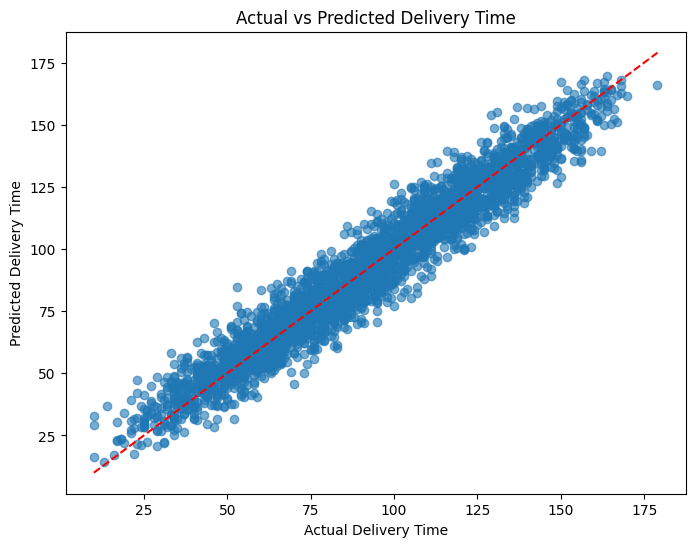

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.show()

In [49]:
print(df["delivery_efficiency_score"].describe())

count    15000.000000
mean        59.165933
std         18.102487
min          1.900000
25%         46.400000
50%         59.100000
75%         72.000000
max        100.000000
Name: delivery_efficiency_score, dtype: float64


In [50]:
print(df[["delivery_time_minutes", "delivery_efficiency_score"]].corr())

                           delivery_time_minutes  delivery_efficiency_score
delivery_time_minutes                   1.000000                  -0.819238
delivery_efficiency_score              -0.819238                   1.000000


In [51]:
df[
    [
        "delivery_time_minutes",
        "estimated_delivery_time",
        "delivery_efficiency_score",
        "delayed_delivery_flag"
    ]
].head(20)

,delivery_time_minutes,estimated_delivery_time,delivery_efficiency_score,delayed_delivery_flag
0,76,68,71.1,False
1,34,40,100.0,False
2,152,142,34.4,False
3,93,93,45.0,False
4,141,134,25.1,False
5,62,68,73.6,False
6,93,109,58.9,False
7,40,53,96.6,False
8,83,63,39.3,True
9,126,131,51.4,False


In [52]:
df["delivery_efficiency_score"].describe()

count    15000.000000
mean        59.165933
std         18.102487
min          1.900000
25%         46.400000
50%         59.100000
75%         72.000000
max        100.000000
Name: delivery_efficiency_score, dtype: float64

In [53]:
df.sort_values("delivery_efficiency_score").head(10)

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
14254,a842f480-4752-4924-a875-c2ac3567104b,3,34,68.412025,10,2,12,39.964046,59,180,...,122.811393,5,False,False,False,False,False,False,1,1.9
10299,741e3c37-0333-4abf-bd69-d44470c7a8d0,3,26,48.880808,9,1,1,39.332787,49,174,...,180.685827,4,False,False,False,True,True,False,1,2.7
14605,a81cc290-154a-4753-994d-9ce75983c27b,3,48,7.802119,9,5,11,34.224149,56,173,...,89.669476,2,False,True,False,False,False,False,1,3.3
14972,b7d0be25-4707-4a86-8ed2-94857ae6266f,2,66,95.510891,22,1,9,38.501120,55,180,...,114.613933,10,True,False,False,False,False,False,4,4.4
8802,55af11e9-f9b7-46cc-a0d9-a9996342840b,3,33,28.229391,13,5,4,38.620813,41,165,...,112.459253,4,False,False,False,False,False,False,1,4.9
7349,133fe443-9c7b-4d85-8139-ea59be7adb9a,3,19,12.885729,12,2,5,37.693004,40,168,...,91.599204,9,False,True,True,False,False,False,2,5.2
4281,785b1481-32d0-40fc-bdf4-0352cc276208,1,66,28.104482,19,5,1,37.325389,56,173,...,116.516020,11,False,False,False,False,False,False,1,5.6
13188,aaa76571-724a-460c-af98-3217e1906078,2,48,10.648180,13,1,6,39.039136,47,163,...,113.295369,3,True,False,False,False,False,False,1,5.7
6857,6d075a43-3342-45c0-89e5-f5b4ef3190f4,2,33,37.358326,23,4,3,35.566761,58,170,...,110.334117,8,False,False,False,True,False,False,2,5.9
3539,62b90c71-3e05-4c9d-8f62-17e0d9aaffd1,3,73,20.146830,19,1,11,34.184261,45,159,...,99.828951,12,False,False,False,True,False,True,1,6.2


In [54]:
df.sort_values("delivery_efficiency_score", ascending=False).head(10)

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
13074,b969043c-74cc-417b-abc7-de898da86d3d,1,74,2.172710,5,4,10,4.874225,37,42,...,118.582902,8,False,False,False,False,True,False,13,100.0
4923,75ac2d64-1c5a-4015-b0eb-94a707f64ce6,2,35,57.819393,0,4,2,1.230576,24,23,...,97.862495,10,False,False,False,False,False,False,11,100.0
10379,a2ce5940-491b-4e38-bb6f-9bb8da42f699,2,56,55.481939,5,3,5,7.663383,16,25,...,198.133307,3,False,False,False,True,True,False,11,100.0
2593,048c6f9e-707e-4772-9cae-d7d69b4aab7b,3,49,65.341245,21,1,4,7.447855,15,28,...,100.903694,8,False,False,False,False,True,False,11,100.0
3591,03b20997-1656-4ba0-9618-98a918639b58,3,72,53.933329,18,4,8,5.883324,7,24,...,111.353838,5,False,False,False,False,False,False,15,100.0
8704,226b4f18-7ddd-4be4-89ca-d4868381b987,1,46,26.754281,2,2,1,0.775821,29,30,...,135.621561,12,False,False,False,False,False,False,12,100.0
13365,ffda3933-4776-4cf3-8868-6b2ffa759312,3,28,41.761259,18,1,2,3.872256,8,19,...,89.910946,9,False,False,False,True,True,False,15,100.0
4899,a86e9cb4-03f0-4650-ac7d-e782c1719616,2,31,27.795125,1,3,4,0.318193,8,15,...,114.965108,1,False,False,False,False,True,False,12,100.0
3162,7c2d3abb-3c5c-46e3-a46b-3033432e61dc,2,44,3.325943,11,6,2,1.402808,20,19,...,110.477635,7,True,False,False,False,True,True,7,100.0
9346,9b18e06a-8217-4a36-93f7-9f306ac96e9c,2,43,13.628260,5,5,10,2.874889,39,40,...,112.180151,8,False,False,True,False,False,False,15,100.0


In [55]:
features = ["estimated_delivery_time"]

X = df[features]
y = df["delivery_time_minutes"]

In [56]:
# Check if efficiency ≈ estimated / actual * 100
calc_efficiency = (
    df["estimated_delivery_time"] /
    df["delivery_time_minutes"]
) * 100

comparison = pd.DataFrame({
    "Actual Efficiency": df["delivery_efficiency_score"],
    "Calculated Efficiency": calc_efficiency.round(1)
})

print(comparison.head(20))

    Actual Efficiency  Calculated Efficiency
0                71.1                   89.5
1               100.0                  117.6
2                34.4                   93.4
3                45.0                  100.0
4                25.1                   95.0
5                73.6                  109.7
6                58.9                  117.2
7                96.6                  132.5
8                39.3                   75.9
9                51.4                  104.0
10               91.4                   86.2
11               56.0                  113.0
12               59.8                   98.9
13               32.0                   97.5
14               32.2                   78.5
15               76.1                  108.3
16               96.6                  114.6
17               56.0                   97.7
18               45.8                  105.1
19               53.6                   96.8


In [58]:
calc_efficiency = (
    df["estimated_delivery_time"] /
    df["delivery_time_minutes"]
) * 100

difference = (
    calc_efficiency.round(1)
    - df["delivery_efficiency_score"]
)

print(difference.describe())
print("Maximum absolute difference:", difference.abs().max())

count    15000.000000
mean        42.198193
std         19.564615
min        -52.400000
25%         29.800000
50%         43.100000
75%         55.300000
max        246.500000
dtype: float64
Maximum absolute difference: 246.5
